### Seed supplement ensemble

In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
fates='/pscratch/sd/j/jneedham/fates-mrv-runs/runs/v11/PA_ensemble_seedrain.E45487965d0-F24e39f9d.2025-08-31/run/PA_ensemble_seedrain.E45487965d0-F24e39f9d.2025-08-31.h0.ensemble.sofar.nc'
fates = xr.open_dataset(fates,  decode_times=False)


In [3]:
nyears = int(len(fates.variables['time'])/12)
print(nyears)
time = fates.variables['time'] / 365.

tave_start = (nyears*12-20*12)
tave_stop = nyears*12

print(tave_start)
print(tave_stop)

cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)
patch_age_bins = fates.variables['fates_levage'][:]

ninst = 100

80
720
960


''

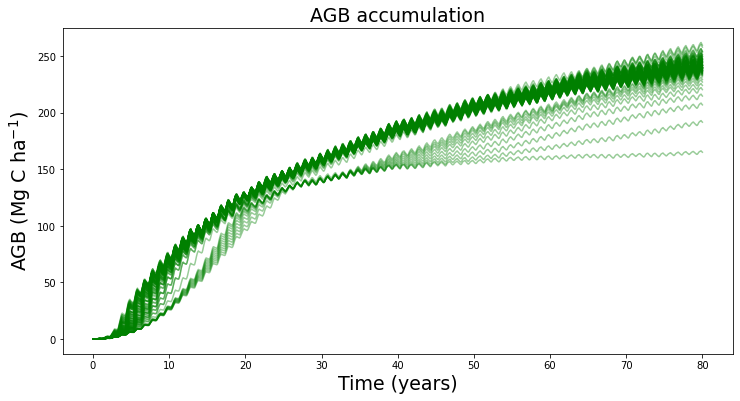

In [4]:
AGB = fates.FATES_VEGC_ABOVEGROUND_SZPF  * 10000 * 0.001 * 2
AGB = AGB.sum(dim='fates_levscpf')

fig1, ((f1ax0)) = plt.subplots(nrows=1,ncols=1, figsize=(12,6))

for  i in range(0,ninst):
    
    f1ax0.plot(time, AGB[i], color='green', alpha = 0.4)    
    
f1ax0.set_title(r'AGB accumulation', fontsize = 19)
f1ax0.set_ylabel(r'AGB (Mg C ha$^{-1}$)', fontsize = 19)
f1ax0.set_xlabel(r'Time (years)', fontsize = 19)    
;


Text(0.02, 0.5, 'Recruitment (ha$^{-1}$ yr$^{-1}$)')

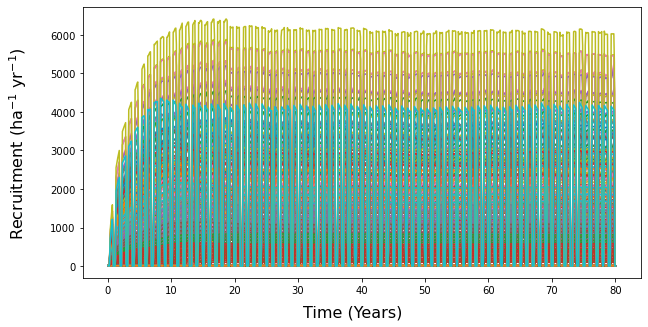

In [5]:
recruit = fates.FATES_RECRUITMENT_PF  * 10000

fig1, axs = plt.subplots(nrows=1,ncols=1, figsize=(10,5))

for i in range(0,ninst):

    axs.plot(time, recruit.isel(fates_levpft=0).isel(record=i),label = 'LD BL D')  
    axs.plot(time, recruit.isel(fates_levpft=1).isel(record=i), label = 'ST BL D')      

fig1.supxlabel(r'Time (Years)', fontsize=16)
fig1.supylabel(r'Recruitment (ha$^{-1}$ yr$^{-1}$)', fontsize=16)

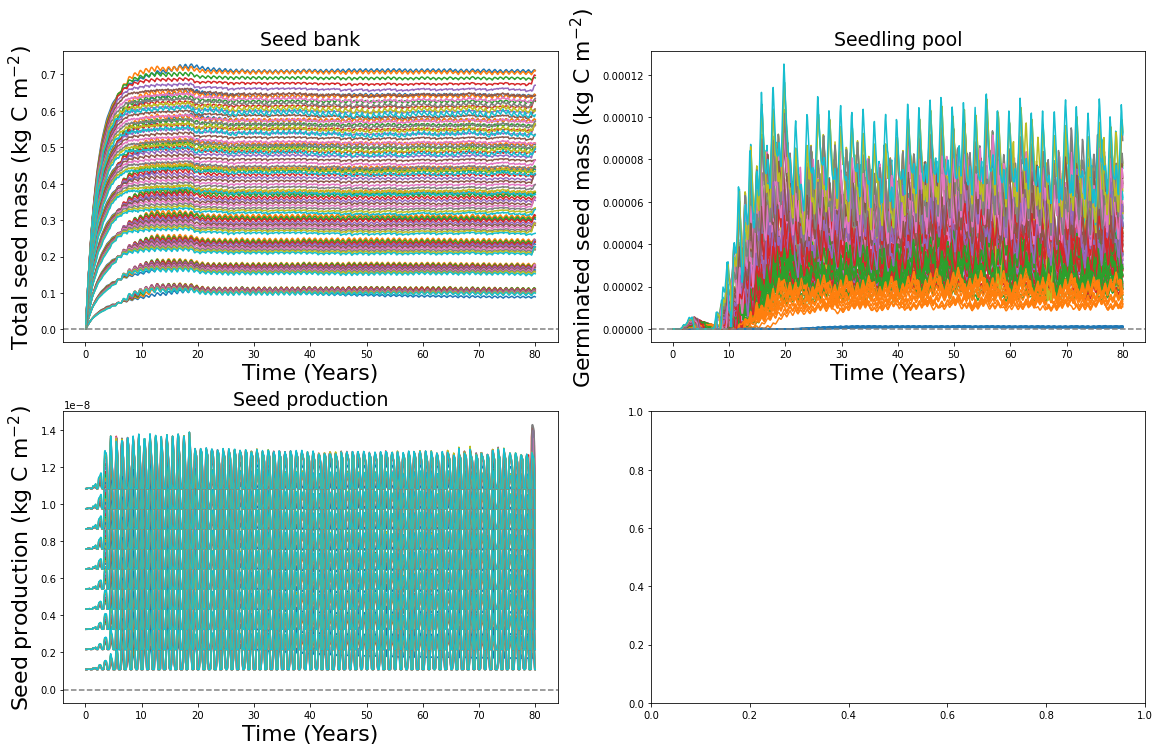

In [6]:
fig1, ((f1ax0, f1ax1), (f1ax2,f1ax3)) = plt.subplots(nrows=2,ncols=2, figsize=(16,10), constrained_layout=True)

for i in range(0,ninst): 
    f1ax0.plot(time, fates.FATES_SEED_BANK.isel(record=i))    
    
    f1ax1.plot(time, fates.FATES_SEEDLING_POOL.isel(record=i))    
    
    f1ax2.plot(time, fates.FATES_SEEDS_IN.isel(record=i))    
    
f1ax0.set_title(r'Seed bank', fontsize = 19)
f1ax0.set_xlabel(r'Time (Years)', fontsize=22)
f1ax0.set_ylabel(r'Total seed mass (kg C m$^{-2}$)', fontsize=22)
f1ax0.axhline(0, linestyle='--', color='grey')
f1ax1.set_title(r'Seedling pool', fontsize = 19)
f1ax1.set_xlabel(r'Time (Years)', fontsize=22)
f1ax1.set_ylabel(r'Germinated seed mass (kg C m$^{-2}$)', fontsize=22)
f1ax1.axhline(0, linestyle='--', color='grey')
f1ax2.set_title(r'Seed production', fontsize = 19)
f1ax2.set_xlabel(r'Time (Years)', fontsize=22)
f1ax2.set_ylabel(r'Seed production (kg C m$^{-2}$)', fontsize=22)
f1ax2.axhline(0, linestyle='--', color='grey')

    